# Week 13 Demo: What Machine Learning Is, and How to Use It on Monthly REIT Data

**QM 2023 — Statistics II / Data Analytics**

## What you will learn

1. What machine learning means in plain language for beginners.
2. Why prediction is different from explanation.
3. Why some finance targets are harder to predict than others.
4. How OLS, Ridge, Lasso, and Random Forest behave on the **monthly REIT panel**.
5. How to judge a model using held-out data instead of in-sample fit.

## Big picture

Econometrics usually asks **"what is the effect of X on Y?"**

Machine learning usually asks **"given the patterns in past data, what is the best guess for the next observation?"**

This notebook keeps the math light and the visuals heavy. We will use real monthly REIT data, move slowly, and stop after each output to ask what it means.


In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.compose import ColumnTransformer
from sklearn.ensemble import RandomForestRegressor
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LinearRegression, RidgeCV, LassoCV
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

plt.style.use("seaborn-v0_8-whitegrid")
sns.set_theme(context="talk", style="whitegrid")
plt.rcParams["figure.dpi"] = 140
plt.rcParams["savefig.dpi"] = 200
plt.rcParams["axes.titlesize"] = 16
plt.rcParams["axes.labelsize"] = 12

NOTEBOOK_DIR = Path.cwd()
if not (NOTEBOOK_DIR / "build_ml_comparison_demo.py").exists():
    NOTEBOOK_DIR = Path(
        r"C:\Users\cas3526\dev\Teaching\Quantitative-Methods-Class\Course-Design\Module 4------------------------------\Week 13 - Machine Learning\demos"
    )

REPO_ROOT = NOTEBOOK_DIR
while REPO_ROOT != REPO_ROOT.parent and not (REPO_ROOT / "Data").exists():
    REPO_ROOT = REPO_ROOT.parent

DATA_PATH = REPO_ROOT / "Data" / "REIT_sample_2004_2024.csv"
FIGURES_DIR = NOTEBOOK_DIR / "figures"
FIGURES_DIR.mkdir(exist_ok=True)

print(f"Notebook directory: {NOTEBOOK_DIR}")
print(f"Data path: {DATA_PATH}")
print(f"Figures will be saved to: {FIGURES_DIR}")


Notebook directory: C:\Users\cas3526\dev\Teaching\Quantitative-Methods-Class\Course-Design\Module 4------------------------------\Week 13 - Machine Learning\demos
Data path: C:\Users\cas3526\dev\Teaching\Quantitative-Methods-Class\Data\REIT_sample_2004_2024.csv
Figures will be saved to: C:\Users\cas3526\dev\Teaching\Quantitative-Methods-Class\Course-Design\Module 4------------------------------\Week 13 - Machine Learning\demos\figures


## Section 1: What machine learning is in plain English

A beginner-friendly definition:

> **Machine learning is a pattern-finding prediction tool.**

We give the algorithm:

- examples from the past,
- a target we care about,
- and a rule for judging forecast quality.

Then it learns a mapping from **features** to a **prediction**.

In this class, that means:

- **Rows** = REIT-month observations
- **Features** = firm characteristics and recent market behavior
- **Target** = something we want to predict next month

The workflow is simple:

1. Choose the prediction target.
2. Split data into training and test periods.
3. Fit several models on the training period.
4. Keep the model that performs best on the unseen test period.

That is the core ML idea. The only real complication is choosing a target where there is enough signal to learn from.


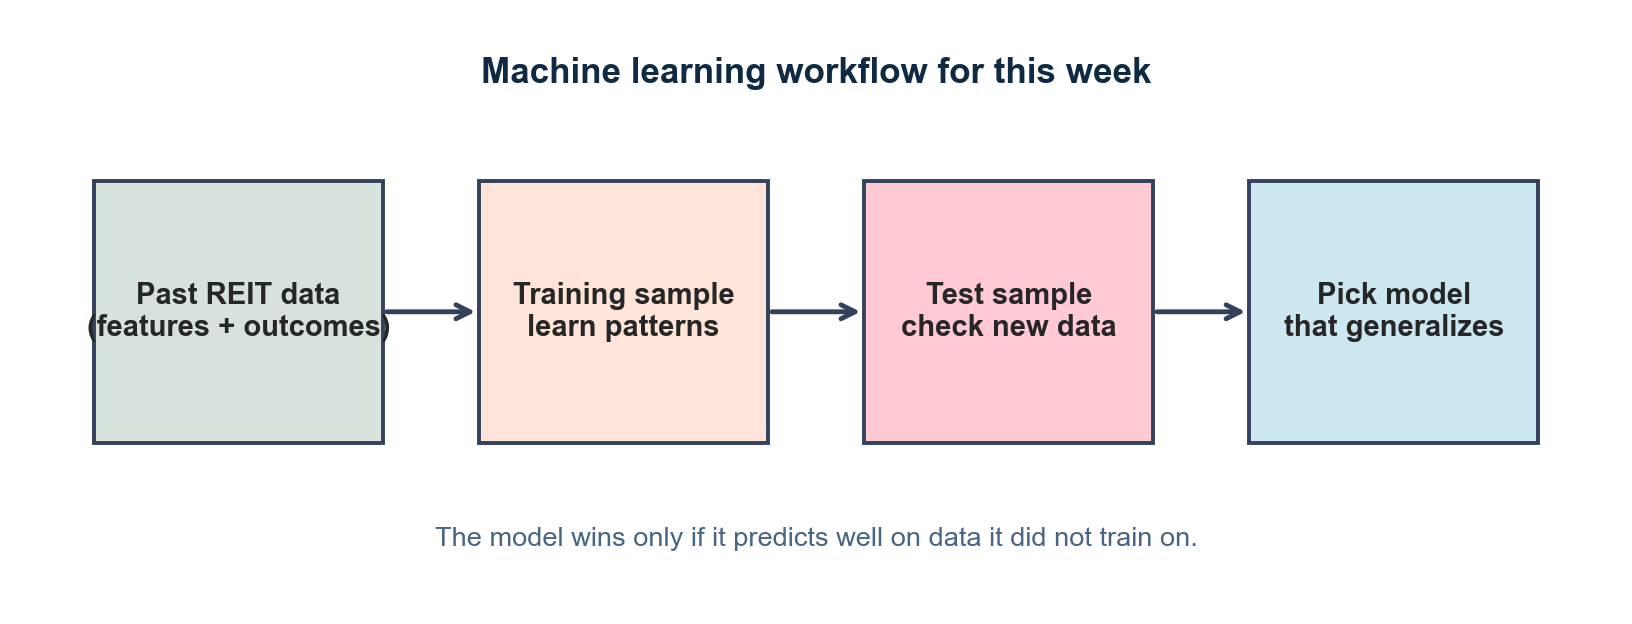

Saved: 00_ml_workflow.png


In [2]:
fig, ax = plt.subplots(figsize=(12, 4.8))
ax.axis("off")

boxes = [
    (0.05, 0.28, 0.18, 0.44, "#D8E2DC", "Past REIT data\n(features + outcomes)"),
    (0.29, 0.28, 0.18, 0.44, "#FFE5D9", "Training sample\nlearn patterns"),
    (0.53, 0.28, 0.18, 0.44, "#FFCAD4", "Test sample\ncheck new data"),
    (0.77, 0.28, 0.18, 0.44, "#CDE7F0", "Pick model\nthat generalizes"),
]

for x, y, w, h, color, label in boxes:
    rect = plt.Rectangle((x, y), w, h, facecolor=color, edgecolor="#33415C", linewidth=2)
    ax.add_patch(rect)
    ax.text(x + w / 2, y + h / 2, label, ha="center", va="center", fontsize=15, weight="bold")

arrow_y = 0.5
for start, end in [(0.23, 0.29), (0.47, 0.53), (0.71, 0.77)]:
    ax.annotate(
        "",
        xy=(end, arrow_y),
        xytext=(start, arrow_y),
        arrowprops=dict(arrowstyle="->", lw=2.5, color="#33415C"),
    )

ax.text(
    0.5,
    0.9,
    "Machine learning workflow for this week",
    ha="center",
    va="center",
    fontsize=18,
    weight="bold",
    color="#102A43",
)
ax.text(
    0.5,
    0.12,
    "The model wins only if it predicts well on data it did not train on.",
    ha="center",
    va="center",
    fontsize=14,
    color="#486581",
)

workflow_path = FIGURES_DIR / "00_ml_workflow.png"
plt.tight_layout()
plt.savefig(workflow_path, bbox_inches="tight")
plt.show()
print(f"Saved: {workflow_path.name}")


**Interpretation checkpoint**

- The workflow is much closer to a forecasting contest than a hypothesis test.
- A model with beautiful in-sample fit can still be useless if it fails on new data.
- That is why the test sample matters so much in machine learning.


## Section 2: Load the monthly REIT panel and build prediction targets

We are using the **monthly REIT sample** from the repo's `Data/` folder.

The first important modeling decision is the target:

- `next_usdret` = next month's return
- `next_realizedvol` = next month's realized volatility

We will look at both, because the choice of target determines whether machine learning has anything useful to learn.


In [3]:
df = pd.read_csv(DATA_PATH)
df["date"] = pd.to_datetime(df["date"])
df = df.sort_values(["permno", "date"]).copy()

df["next_usdret"] = df.groupby("permno")["usdret"].shift(-1)
df["next_realizedvol"] = df.groupby("permno")["realizedvol"].shift(-1)

print("Shape:", df.shape)
print("Date range:", df["date"].min().date(), "to", df["date"].max().date())
print("Unique REITs:", df["permno"].nunique())

display_cols = [
    "permno", "ticker", "date", "usdret", "realizedvol", "beta", "lnmcap",
    "debt_at", "ret12", "next_usdret", "next_realizedvol"
]
display(df[display_cols].head(10))


Shape: (29927, 53)
Date range: 2004-01-30 to 2024-12-31
Unique REITs: 254


,permno,ticker,date,usdret,realizedvol,beta,lnmcap,debt_at,ret12,next_usdret,next_realizedvol
0,10952,UNII,2004-01-30,0.0628,0.008035,-0.239704,12.157351,0.769807,-0.146586,0.0417,0.010723
1,10952,UNII,2004-02-27,0.0417,0.010723,-0.251075,12.186468,0.769807,-0.135296,0.0442,0.012892
2,10952,UNII,2004-03-31,0.0442,0.012892,-0.256402,12.229671,0.769807,-0.018348,-0.1790,0.022824
3,10952,UNII,2004-04-30,-0.1790,0.022824,-0.206795,12.163752,0.474596,-0.228104,-0.0202,0.015220
4,10952,UNII,2004-05-28,-0.0202,0.015220,-0.201723,12.123466,0.474596,-0.260411,0.0268,0.007091
5,10952,UNII,2004-06-30,0.0268,0.007091,-0.204420,12.149923,0.474596,-0.246243,0.0766,0.028154
6,10952,UNII,2004-07-30,0.0766,0.028154,-0.216841,12.223720,0.522539,-0.293123,0.1136,0.015314
7,10952,UNII,2004-08-31,0.1136,0.015314,-0.230151,12.314832,0.522539,-0.435836,0.0295,0.017153
8,10952,UNII,2004-09-30,0.0295,0.017153,-0.224306,12.343925,0.522539,-0.345127,-0.0301,0.007267
9,10952,UNII,2004-10-29,-0.0301,0.007267,-0.234876,12.313355,0.540468,0.232365,0.0218,0.013260


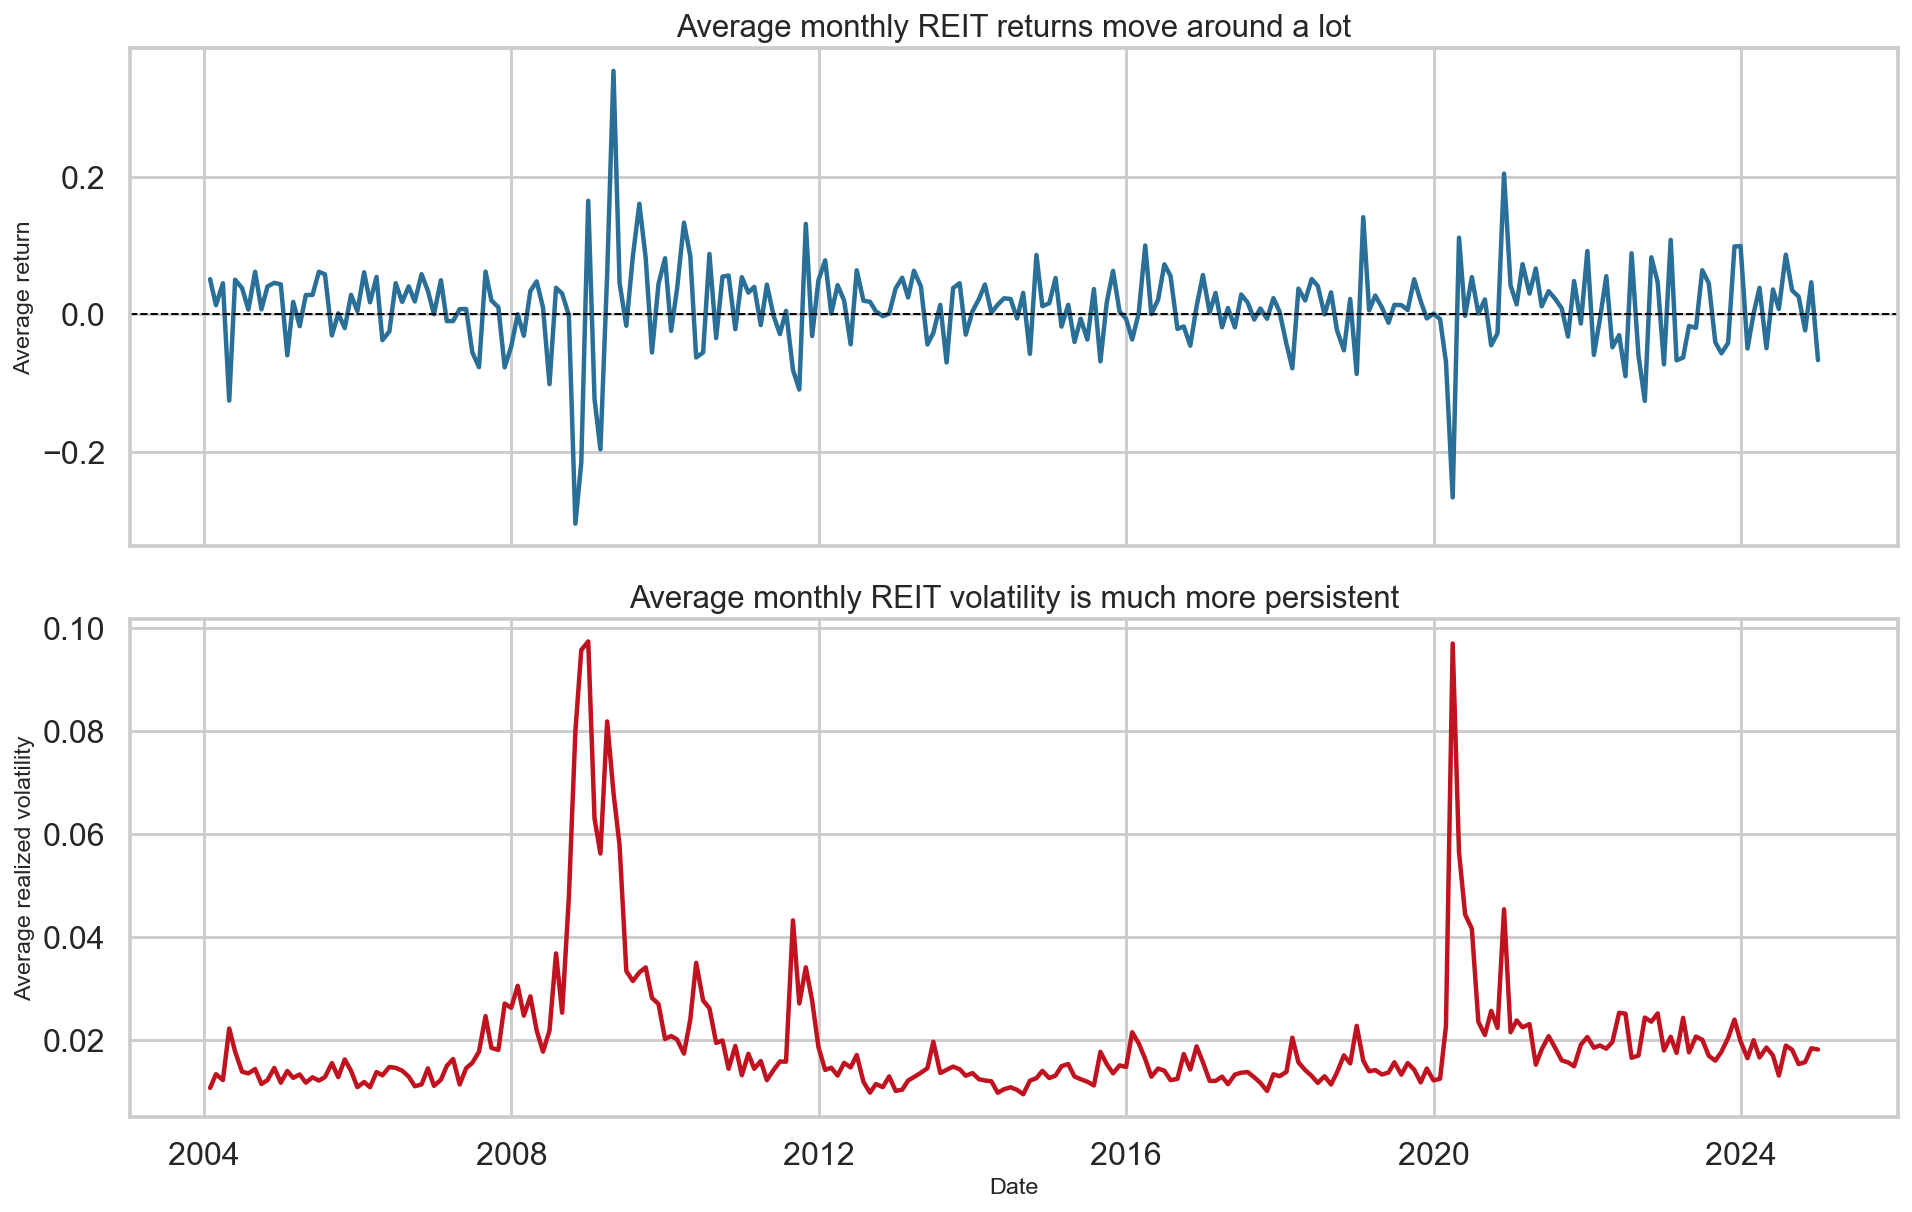

Saved: 01_market_backdrop.png


In [4]:
monthly_summary = (
    df.groupby("date")
    .agg(
        avg_return=("usdret", "mean"),
        median_return=("usdret", "median"),
        avg_volatility=("realizedvol", "mean"),
        reit_count=("permno", "nunique"),
    )
    .reset_index()
)

fig, axes = plt.subplots(2, 1, figsize=(14, 9), sharex=True)

sns.lineplot(data=monthly_summary, x="date", y="avg_return", ax=axes[0], color="#2A6F97", linewidth=2.3)
axes[0].axhline(0, color="black", linestyle="--", linewidth=1)
axes[0].set_title("Average monthly REIT returns move around a lot")
axes[0].set_ylabel("Average return")

sns.lineplot(data=monthly_summary, x="date", y="avg_volatility", ax=axes[1], color="#C1121F", linewidth=2.3)
axes[1].set_title("Average monthly REIT volatility is much more persistent")
axes[1].set_ylabel("Average realized volatility")
axes[1].set_xlabel("Date")

backdrop_path = FIGURES_DIR / "01_market_backdrop.png"
plt.tight_layout()
plt.savefig(backdrop_path, bbox_inches="tight")
plt.show()
print(f"Saved: {backdrop_path.name}")


**What do you notice?**

- Returns bounce above and below zero quickly.
- Volatility moves in longer swings, which usually makes it easier to forecast.
- That difference is exactly why finance prediction problems are not all equally hard.


## Section 3: A quick visual test of "easy" versus "hard" prediction

Before we fit any model, it helps to ask a simple question:

**Does today's value line up with next month's value at all?**

If the answer is "barely," then even fancy machine learning will struggle.


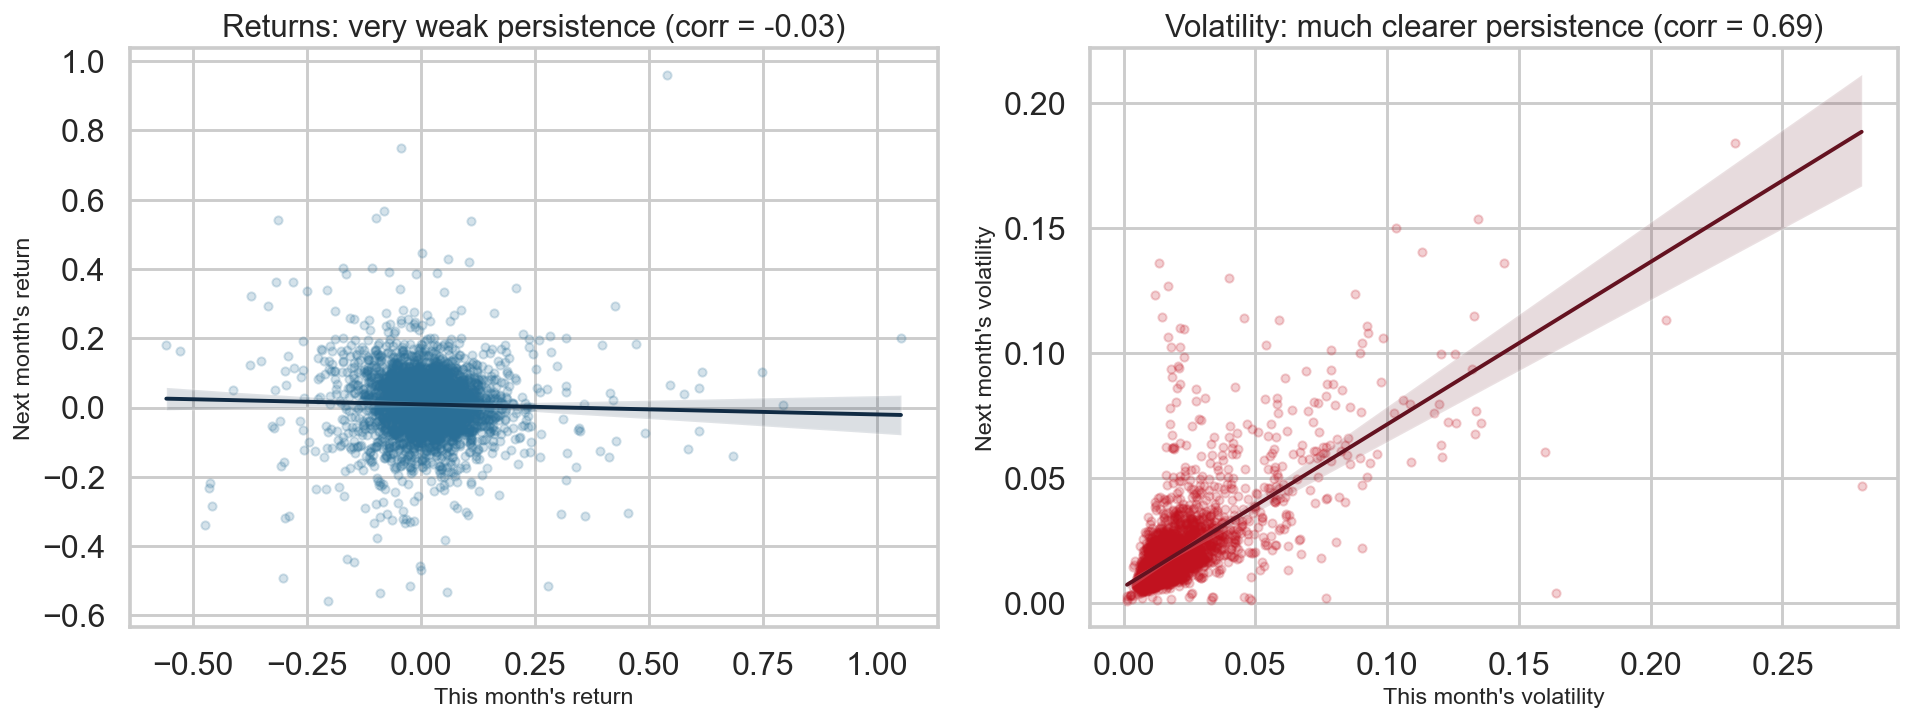

Saved: 02_returns_vs_volatility_signal.png


In [5]:
compare_df = df[["usdret", "next_usdret", "realizedvol", "next_realizedvol"]].dropna().sample(
    n=4000, random_state=42
)

corr_returns = compare_df["usdret"].corr(compare_df["next_usdret"])
corr_vol = compare_df["realizedvol"].corr(compare_df["next_realizedvol"])

fig, axes = plt.subplots(1, 2, figsize=(14, 5.5))

sns.regplot(
    data=compare_df,
    x="usdret",
    y="next_usdret",
    scatter_kws={"alpha": 0.2, "s": 18, "color": "#2A6F97"},
    line_kws={"color": "#102A43", "linewidth": 2},
    ax=axes[0],
)
axes[0].set_title(f"Returns: very weak persistence (corr = {corr_returns:.2f})")
axes[0].set_xlabel("This month's return")
axes[0].set_ylabel("Next month's return")

sns.regplot(
    data=compare_df,
    x="realizedvol",
    y="next_realizedvol",
    scatter_kws={"alpha": 0.2, "s": 18, "color": "#C1121F"},
    line_kws={"color": "#641220", "linewidth": 2},
    ax=axes[1],
)
axes[1].set_title(f"Volatility: much clearer persistence (corr = {corr_vol:.2f})")
axes[1].set_xlabel("This month's volatility")
axes[1].set_ylabel("Next month's volatility")

difficulty_path = FIGURES_DIR / "02_returns_vs_volatility_signal.png"
plt.tight_layout()
plt.savefig(difficulty_path, bbox_inches="tight")
plt.show()
print(f"Saved: {difficulty_path.name}")


**Interpretation checkpoint**

- This is the first major ML lesson: **the target matters.**
- Monthly returns are noisy, so prediction quality will usually look disappointing.
- Monthly volatility is more persistent, so models have a fairer chance to detect useful patterns.

For the full model comparison below, we will predict **next month's realized volatility**.


## Section 4: Build a teachable modeling sample

To keep the demo focused on the modern REIT market, we use observations from **2010 onward**.

Our feature set includes:

- recent returns (`usdret`, `ret1`, `ret6`, `ret12`)
- risk measures (`beta`, `realizedvol`, `ivol_capm_21d`, `rvol_21d`)
- firm characteristics (`lnmcap`, `btm`, `debt_at`, `roe`, `age`, `div12m_me`, `dolvol`)

These are intuitive because they mix:

- how the stock has been behaving recently,
- how risky it looks,
- and what kind of REIT firm it is.


In [6]:
feature_cols = [
    "usdret",
    "ret1",
    "ret6",
    "ret12",
    "beta",
    "lnmcap",
    "btm",
    "debt_at",
    "roe",
    "age",
    "div12m_me",
    "dolvol",
    "realizedvol",
    "ivol_capm_21d",
    "rvol_21d",
]

model_df = (
    df.loc[df["date"] >= "2010-01-01", ["date", "permno", "ticker", "next_realizedvol"] + feature_cols]
    .replace([np.inf, -np.inf], np.nan)
    .dropna(subset=["next_realizedvol"])
    .copy()
)

monthly_dates = np.sort(model_df["date"].unique())
split_idx = int(len(monthly_dates) * 0.8)
split_date = monthly_dates[split_idx]

train_df = model_df[model_df["date"] < split_date].copy()
test_df = model_df[model_df["date"] >= split_date].copy()

print("Modeling rows:", f"{len(model_df):,}")
print("Training rows:", f"{len(train_df):,}")
print("Test rows:", f"{len(test_df):,}")
print("Train period:", train_df["date"].min().date(), "to", train_df["date"].max().date())
print("Test period:", test_df["date"].min().date(), "to", test_df["date"].max().date())

missing_summary = model_df[feature_cols].isna().mean().sort_values(ascending=False).head(8)
display(missing_summary.rename("missing_share").to_frame())


Modeling rows: 22,597
Training rows: 18,143
Test rows: 4,454
Train period: 2010-01-29 to 2021-11-30
Test period: 2021-12-31 to 2024-11-29


,missing_share
beta,0.081781
ret12,0.061778
roe,0.061557
div12m_me,0.042528
ret6,0.031287
btm,0.030048
usdret,0.005266
ret1,0.005266


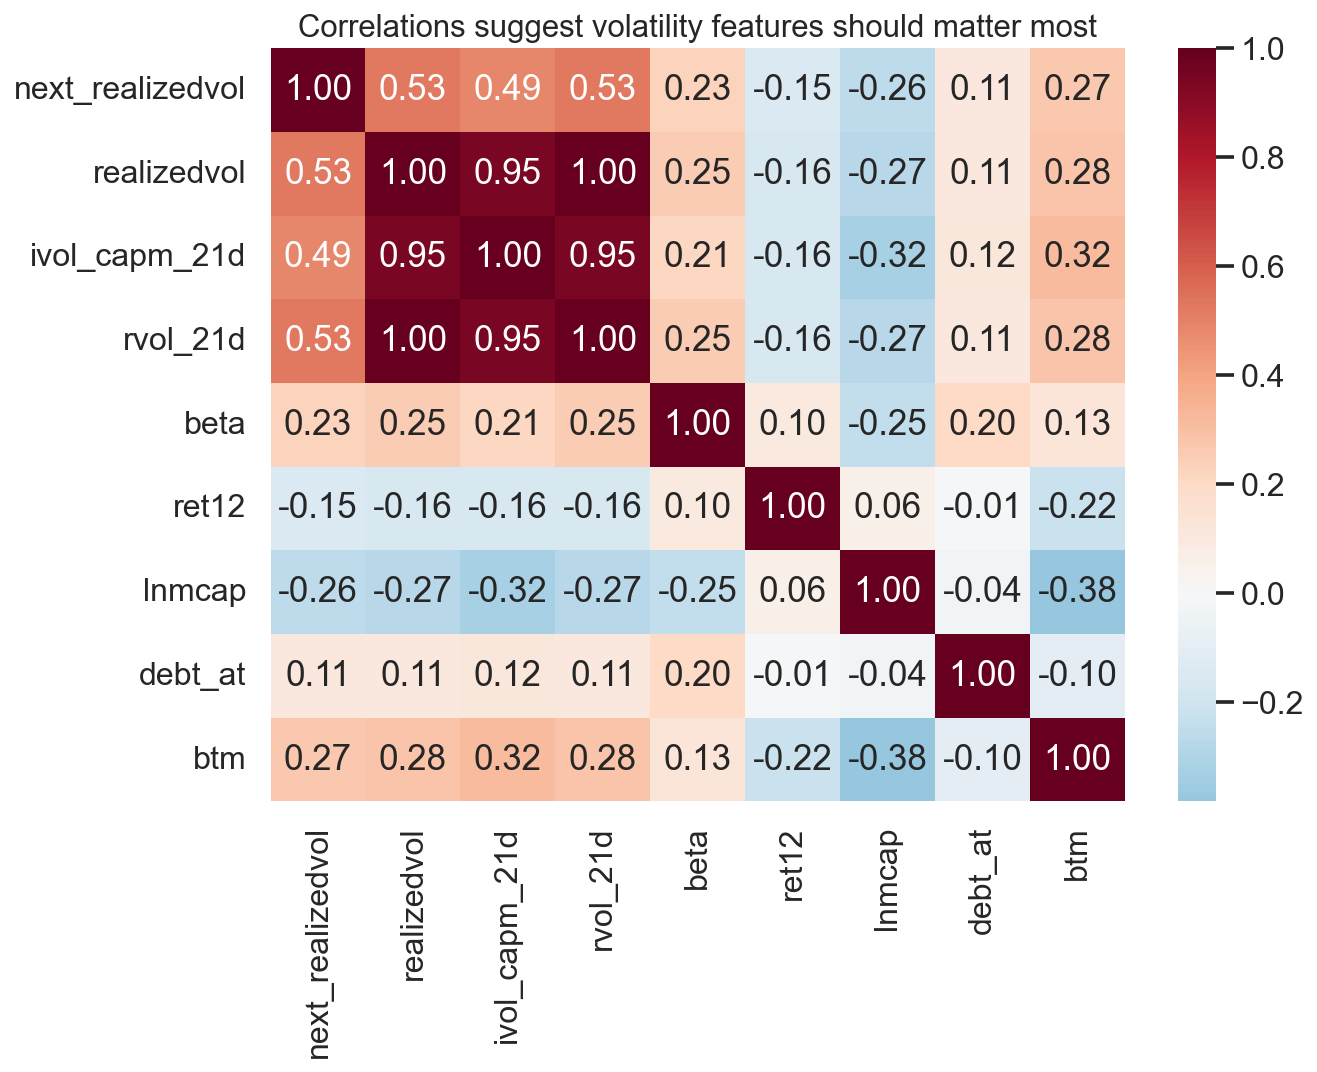

Saved: 03_feature_correlation_heatmap.png


In [7]:
corr_cols = ["next_realizedvol", "realizedvol", "ivol_capm_21d", "rvol_21d", "beta", "ret12", "lnmcap", "debt_at", "btm"]
corr_matrix = model_df[corr_cols].corr()

fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(corr_matrix, cmap="RdBu_r", center=0, annot=True, fmt=".2f", ax=ax)
ax.set_title("Correlations suggest volatility features should matter most")

corr_path = FIGURES_DIR / "03_feature_correlation_heatmap.png"
plt.tight_layout()
plt.savefig(corr_path, bbox_inches="tight")
plt.show()
print(f"Saved: {corr_path.name}")


**Why this picture matters**

- `realizedvol`, `ivol_capm_21d`, and `rvol_21d` all line up strongly with next month's volatility.
- That means a simple linear model might already do well.
- A complex model like Random Forest still has to prove that the extra flexibility helps on the test sample.


## Section 5: Fit four competing models

We will compare:

- **OLS**: the familiar baseline
- **Ridge**: shrinks coefficients smoothly
- **Lasso**: shrinks and can drop weak features
- **Random Forest**: nonlinear ensemble of many trees

The key rule is that every model sees the **same training period** and the **same test period**.


In [8]:
X_train = train_df[feature_cols]
y_train = train_df["next_realizedvol"]
X_test = test_df[feature_cols]
y_test = test_df["next_realizedvol"]

linear_preprocessor = ColumnTransformer(
    transformers=[
        (
            "num",
            Pipeline(
                steps=[
                    ("imputer", SimpleImputer(strategy="median")),
                    ("scaler", StandardScaler()),
                ]
            ),
            feature_cols,
        )
    ]
)

tree_preprocessor = ColumnTransformer(
    transformers=[
        (
            "num",
            Pipeline(steps=[("imputer", SimpleImputer(strategy="median"))]),
            feature_cols,
        )
    ]
)

models = {
    "OLS": Pipeline(
        [("preprocessor", linear_preprocessor), ("model", LinearRegression())]
    ),
    "Ridge": Pipeline(
        [
            ("preprocessor", linear_preprocessor),
            ("model", RidgeCV(alphas=np.logspace(-3, 3, 25))),
        ]
    ),
    "Lasso": Pipeline(
        [
            ("preprocessor", linear_preprocessor),
            ("model", LassoCV(alphas=np.logspace(-3, 1, 20), cv=5, max_iter=20000)),
        ]
    ),
    "Random Forest": Pipeline(
        [
            ("preprocessor", tree_preprocessor),
            (
                "model",
                RandomForestRegressor(
                    n_estimators=220,
                    max_depth=8,
                    min_samples_leaf=25,
                    random_state=42,
                    n_jobs=-1,
                ),
            ),
        ]
    ),
}

results = []
fitted_models = {}

for name, model in models.items():
    model.fit(X_train, y_train)
    fitted_models[name] = model

    train_pred = model.predict(X_train)
    test_pred = model.predict(X_test)

    results.append(
        {
            "model": name,
            "train_r2": r2_score(y_train, train_pred),
            "test_r2": r2_score(y_test, test_pred),
            "test_rmse": np.sqrt(mean_squared_error(y_test, test_pred)),
            "test_mae": mean_absolute_error(y_test, test_pred),
            "overfit_gap": r2_score(y_train, train_pred) - r2_score(y_test, test_pred),
        }
    )

results_df = pd.DataFrame(results).sort_values("test_r2", ascending=False).reset_index(drop=True)
display(results_df.style.format({"train_r2": "{:.3f}", "test_r2": "{:.3f}", "test_rmse": "{:.4f}", "test_mae": "{:.4f}", "overfit_gap": "{:.3f}"}))


,model,train_r2,test_r2,test_rmse,test_mae,overfit_gap
0,Lasso,0.299,0.342,0.0079,0.0050,-0.043
1,OLS,0.321,0.333,0.0080,0.0051,-0.011
2,Ridge,0.321,0.333,0.0080,0.0051,-0.011
3,Random Forest,0.451,0.268,0.0083,0.0055,0.183


C:\Users\cas3526\AppData\Local\Temp\ipykernel_64312\1785056585.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=rank_df, x="test_r2", y="model", palette="crest", ax=axes[0])
C:\Users\cas3526\AppData\Local\Temp\ipykernel_64312\1785056585.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=rank_df, x="overfit_gap", y="model", palette="flare", ax=axes[1])


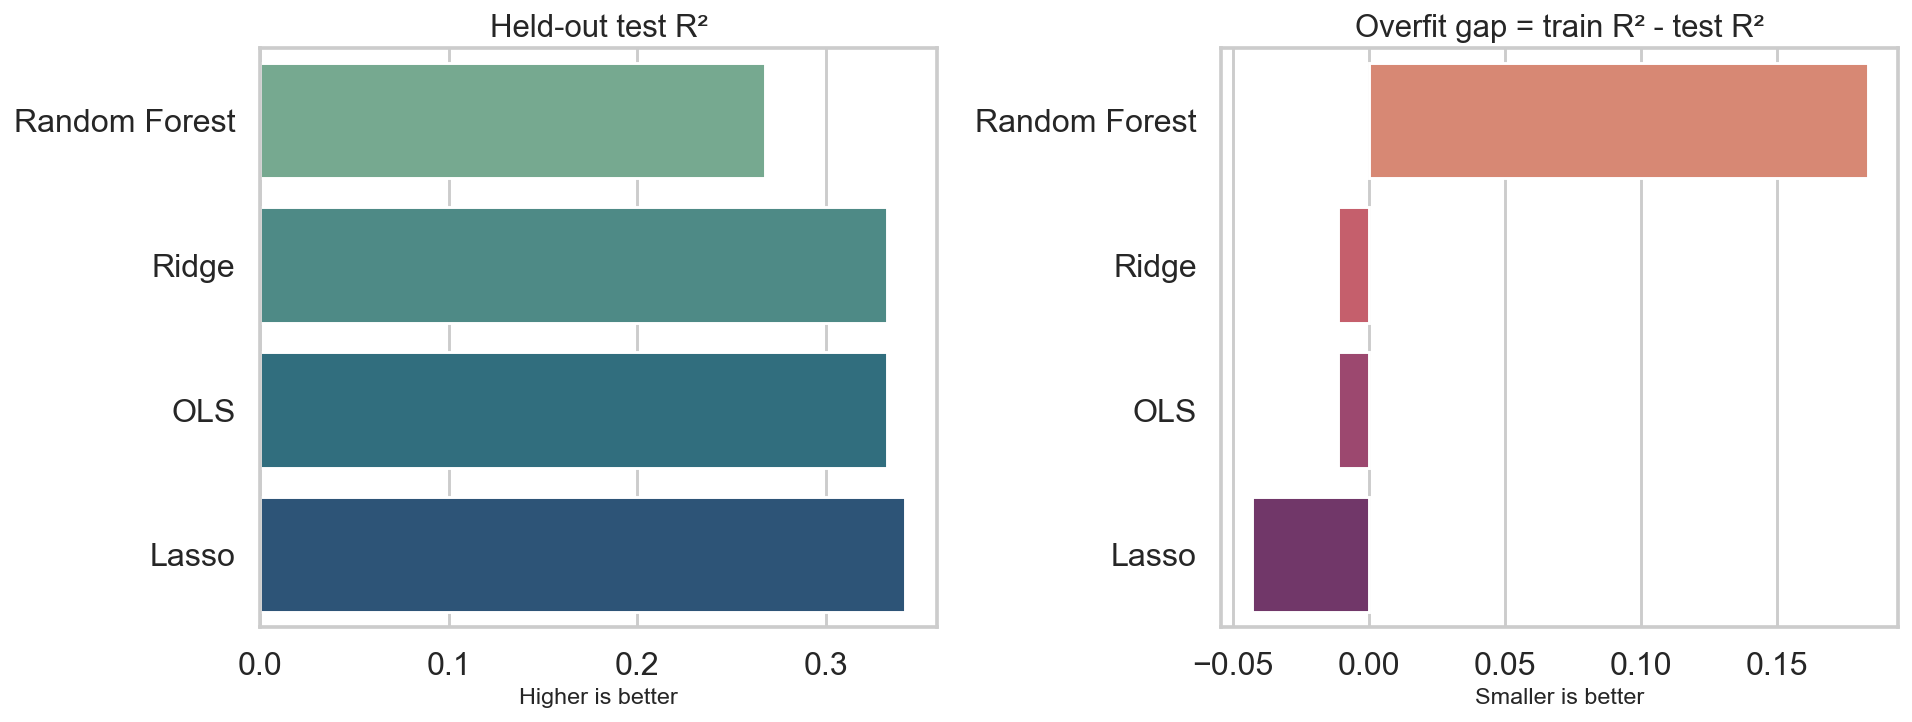

Saved: 04_model_comparison.png


In [9]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5.5))

rank_df = results_df.sort_values("test_r2", ascending=True)
sns.barplot(data=rank_df, x="test_r2", y="model", palette="crest", ax=axes[0])
axes[0].set_title("Held-out test R²")
axes[0].set_xlabel("Higher is better")
axes[0].set_ylabel("")

sns.barplot(data=rank_df, x="overfit_gap", y="model", palette="flare", ax=axes[1])
axes[1].set_title("Overfit gap = train R² - test R²")
axes[1].set_xlabel("Smaller is better")
axes[1].set_ylabel("")

comparison_path = FIGURES_DIR / "04_model_comparison.png"
plt.tight_layout()
plt.savefig(comparison_path, bbox_inches="tight")
plt.show()
print(f"Saved: {comparison_path.name}")


**Interpretation checkpoint**

- In this dataset, the regularized linear models are very competitive.
- That tells us the main signal is fairly stable and mostly linear.
- Random Forest is flexible, but flexibility is only helpful when it improves **test** performance.
- This is a useful classroom result because it shows that "more complicated" does not automatically mean "better."


## Section 6: Look directly at the best model's predictions

A summary table is useful, but students usually understand ML better when they can **see actual values against predicted values**.


C:\Users\cas3526\AppData\Local\Temp\ipykernel_64312\345713424.py:28: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=top_errors.sort_values("abs_error"), x="abs_error", y="label", palette="rocket", ax=axes[1])


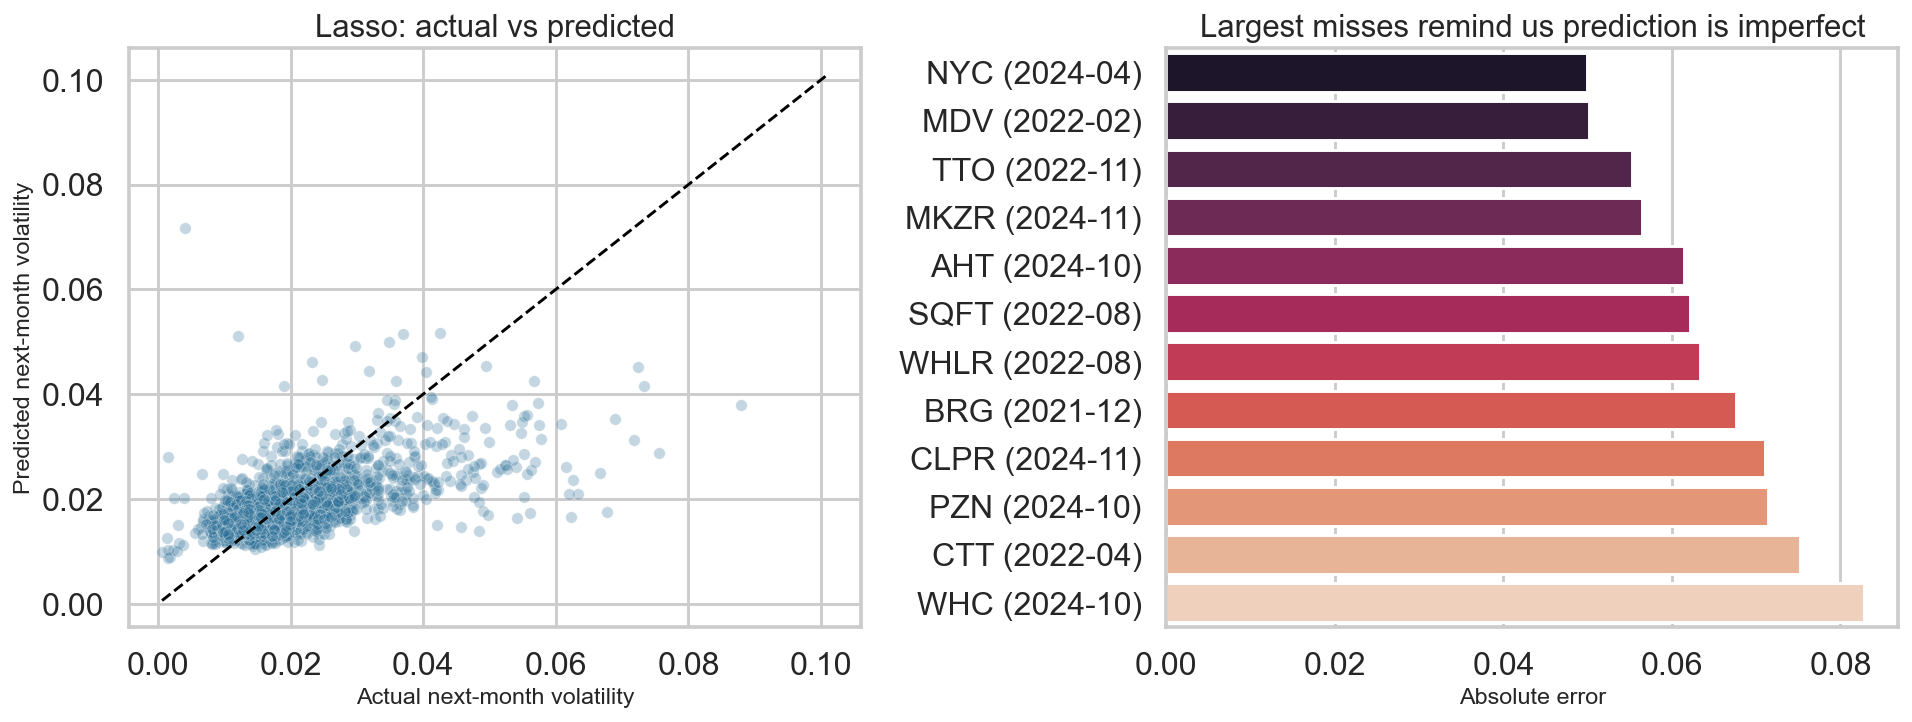

Saved: 05_best_model_predictions.png


In [10]:
best_model_name = results_df.loc[0, "model"]
best_model = fitted_models[best_model_name]

test_plot_df = test_df[["date", "ticker", "next_realizedvol"]].copy()
test_plot_df["prediction"] = best_model.predict(X_test)
test_plot_df["abs_error"] = (test_plot_df["next_realizedvol"] - test_plot_df["prediction"]).abs()

fig, axes = plt.subplots(1, 2, figsize=(14, 5.5))

sns.scatterplot(
    data=test_plot_df.sample(min(len(test_plot_df), 2500), random_state=42),
    x="next_realizedvol",
    y="prediction",
    alpha=0.28,
    s=35,
    color="#2A6F97",
    ax=axes[0],
)
low = min(test_plot_df["next_realizedvol"].min(), test_plot_df["prediction"].min())
high = max(test_plot_df["next_realizedvol"].max(), test_plot_df["prediction"].max())
axes[0].plot([low, high], [low, high], linestyle="--", color="black", linewidth=1.5)
axes[0].set_title(f"{best_model_name}: actual vs predicted")
axes[0].set_xlabel("Actual next-month volatility")
axes[0].set_ylabel("Predicted next-month volatility")

top_errors = test_plot_df.nlargest(12, "abs_error").copy()
top_errors["label"] = top_errors["ticker"] + " (" + top_errors["date"].dt.strftime("%Y-%m") + ")"
sns.barplot(data=top_errors.sort_values("abs_error"), x="abs_error", y="label", palette="rocket", ax=axes[1])
axes[1].set_title("Largest misses remind us prediction is imperfect")
axes[1].set_xlabel("Absolute error")
axes[1].set_ylabel("")

prediction_path = FIGURES_DIR / "05_best_model_predictions.png"
plt.tight_layout()
plt.savefig(prediction_path, bbox_inches="tight")
plt.show()
print(f"Saved: {prediction_path.name}")


**What should students notice here?**

- The cloud of points is clearly upward sloping, so the model is learning something real.
- But the misses are also real. ML gives better guesses, not certainty.
- Finance data is noisy, so a "good" model is usually one that is directionally useful and stable out of sample.


## Section 7: Which features matter most?

We finish with a simple interpretability check:

- OLS and Lasso give coefficients.
- Random Forest gives feature importances.

These are not identical objects, but they still tell us whether the models are leaning on the same broad signals.


C:\Users\cas3526\AppData\Local\Temp\ipykernel_64312\3971788296.py:25: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=rf_importance.values, y=rf_importance.index, palette="mako", ax=axes[1])


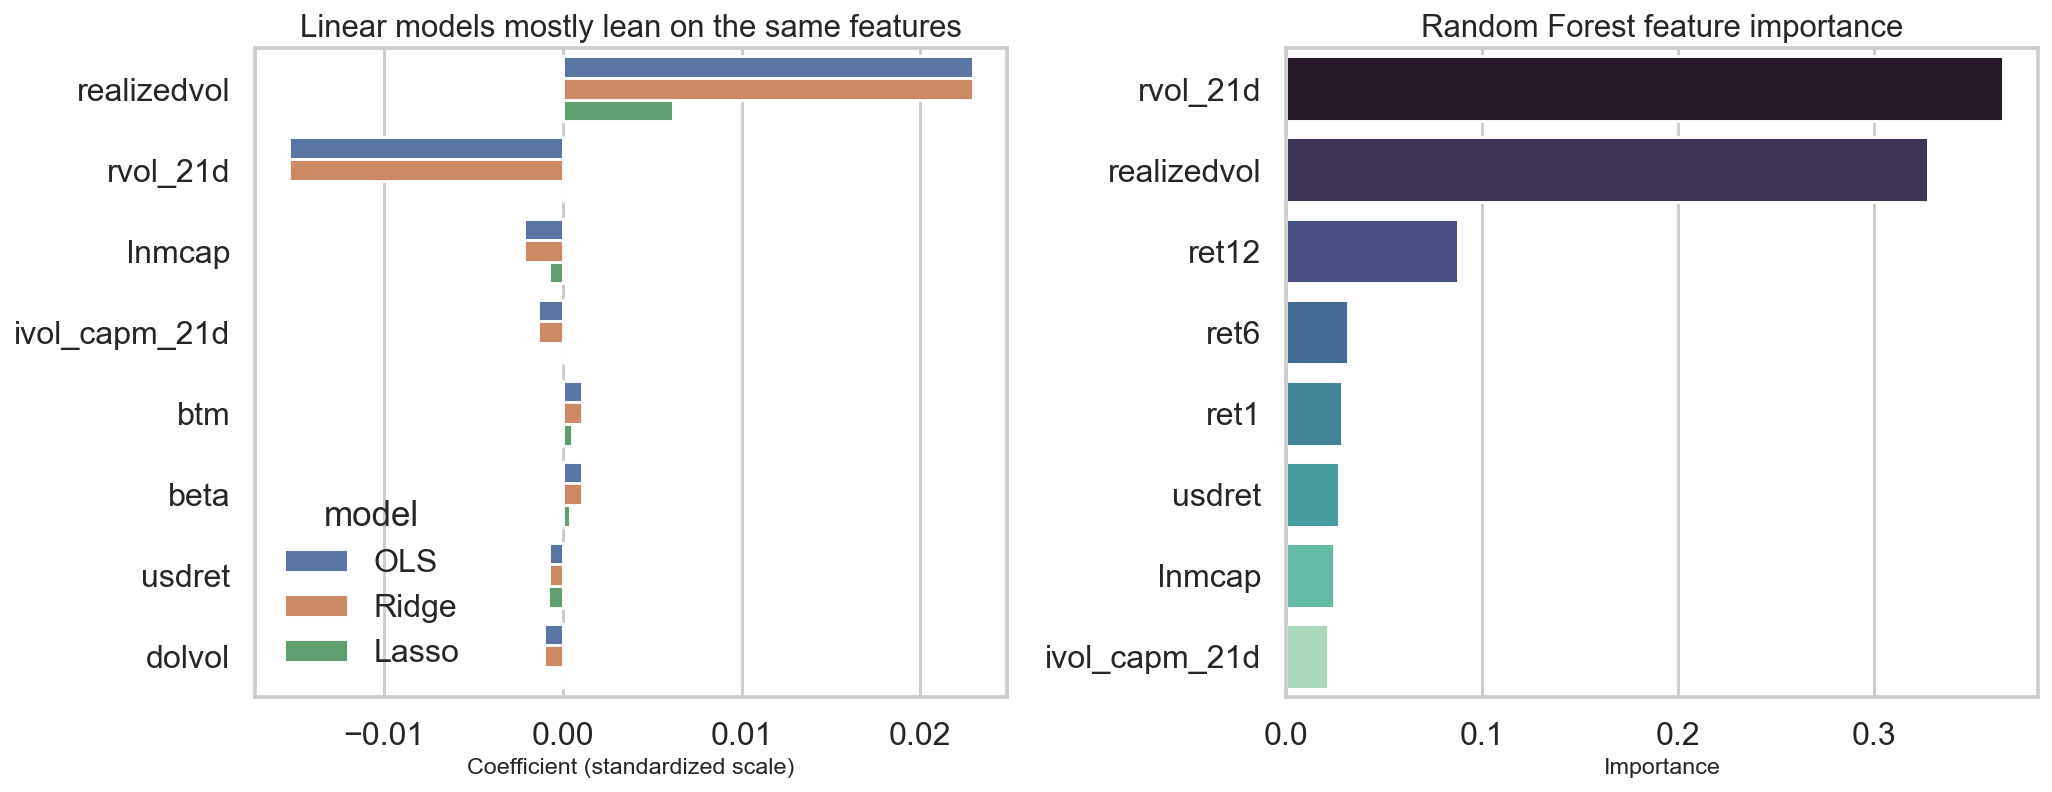

Saved: 06_feature_importance.png


In [11]:
coefficient_models = {}
for model_name in ["OLS", "Ridge", "Lasso"]:
    fitted = fitted_models[model_name]
    coef = fitted.named_steps["model"].coef_
    coefficient_models[model_name] = pd.Series(coef, index=feature_cols)

coef_df = pd.concat(coefficient_models, axis=1).reset_index().rename(columns={"index": "feature"})
coef_df["avg_abs_weight"] = coef_df[["OLS", "Ridge", "Lasso"]].abs().mean(axis=1)
top_linear = coef_df.sort_values("avg_abs_weight", ascending=False).head(8)

rf_importance = pd.Series(
    fitted_models["Random Forest"].named_steps["model"].feature_importances_,
    index=feature_cols,
    name="Random Forest importance",
).sort_values(ascending=False).head(8)

fig, axes = plt.subplots(1, 2, figsize=(15, 6))

linear_plot = top_linear.melt(id_vars="feature", value_vars=["OLS", "Ridge", "Lasso"], var_name="model", value_name="weight")
sns.barplot(data=linear_plot, x="weight", y="feature", hue="model", ax=axes[0])
axes[0].set_title("Linear models mostly lean on the same features")
axes[0].set_xlabel("Coefficient (standardized scale)")
axes[0].set_ylabel("")

sns.barplot(x=rf_importance.values, y=rf_importance.index, palette="mako", ax=axes[1])
axes[1].set_title("Random Forest feature importance")
axes[1].set_xlabel("Importance")
axes[1].set_ylabel("")

importance_path = FIGURES_DIR / "06_feature_importance.png"
plt.tight_layout()
plt.savefig(importance_path, bbox_inches="tight")
plt.show()
print(f"Saved: {importance_path.name}")


**Interpretation checkpoint**

- Volatility measures dominate the ranking, which matches the earlier correlation picture.
- That is a reassuring sign: the models are not finding a mysterious black-box signal.
- Instead, they are mostly formalizing an intuitive idea:
  **high-risk REITs this month are likely to remain high-risk next month.**


## Section 8: Final takeaway

Here is the Week 13 lesson in one sentence:

> Machine learning is a disciplined way to make predictions on new data, not a magic button that always beats simpler models.

For this monthly REIT example:

- next-month **returns** are hard to predict,
- next-month **volatility** is more predictable,
- regularized linear models perform well,
- and model quality must be judged on the **test sample**.

That is exactly the mindset students need before the assignment.


In [12]:
recap = pd.DataFrame(
    {
        "Key point": [
            "What ML is",
            "Hard target",
            "Better target",
            "Best model here",
            "Main decision rule",
        ],
        "Takeaway": [
            "A pattern-finding prediction tool",
            "Next-month REIT returns",
            "Next-month REIT volatility",
            results_df.loc[0, "model"],
            "Prefer stronger test performance and smaller overfit gap",
        ],
    }
)

display(recap)
print("Saved figures:")
for figure_path in sorted(FIGURES_DIR.glob("*.png")):
    print(" -", figure_path.name)


,Key point,Takeaway
0,What ML is,A pattern-finding prediction tool
1,Hard target,Next-month REIT returns
2,Better target,Next-month REIT volatility
3,Best model here,Lasso
4,Main decision rule,Prefer stronger test performance and smaller o...


Saved figures:
 - 00_ml_workflow.png
 - 01_market_backdrop.png
 - 02_returns_vs_volatility_signal.png
 - 03_feature_correlation_heatmap.png
 - 04_model_comparison.png
 - 05_best_model_predictions.png
 - 06_feature_importance.png
